# EPA Hyperparameter Tuning v2 -- Per-Layer Coefficient Tuning

Two-phase greedy approach for finding optimal per-layer steering coefficients.

**Phase 1** -- Individual Layer Sweep: test every layer independently with multiple coefficients.
**Simple Independent** -- Combine all effective layers with their best coefficients (assumes independence).
**Phase 2** -- Greedy Forward Selection: starting from best layer, add layers one at a time, re-tuning.

**Prerequisites:** Run `hyperparameter_tuning.ipynb` Cells 1-3 first to generate `epa_tuning_dataset.json`.
**Estimated time:** ~50 min on a single GPU (after model loading).

In [1]:
# === Cell 1: Setup & Imports ===
import sys; sys.path.append('../..')
import os, json, pickle, itertools
from datetime import datetime
import torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from repe import repe_pipeline_registry
from repe.rep_control_reading_vec import WrappedReadingVecModel
repe_pipeline_registry()
from examples.act_new.act_core import EPA
from examples.act_new.epa_calibration import BehaviorPromptGenerator
from examples.act_new.utils import format_llama3_prompt, make_epa_activations
print("All imports OK.")

c:\Users\Kyra\mambaforge-pypy3\envs\repeng\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


In [2]:
# === Cell 2: Load Model & Directions ===
with open("epa_directions.pkl", 'rb') as f:
    directions_data = pickle.load(f)
rep_readers = directions_data['rep_readers']
hidden_layers = directions_data['hidden_layers']
model_name = directions_data['model_name']
print(f"Loaded directions: {model_name}, {len(hidden_layers)} layers ({hidden_layers[0]}..{hidden_layers[-1]})")

model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token

n_layers = len(model.model.layers)
def neg_to_pos(x):
    if isinstance(x, (list, tuple)): return [n_layers + k for k in x]
    return n_layers + x
print(f"Model loaded ({n_layers} layers). Direction keys: negative indices.")

Loaded directions: meta-llama/Llama-3.1-8B-Instruct, 31 layers (-1..-31)


Loading checkpoint shards: 100%|██████████| 4/4 [00:12<00:00,  3.17s/it]


Model loaded (32 layers). Direction keys: negative indices.


In [3]:
# === Cell 3: Load Saved Dataset ===
DATASET_PATH = "epa_tuning_dataset.json"
with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)
utterances = dataset['utterances']
LIKERT_OPTIONS = ["Very low", "Low", "Somewhat low", "Neutral", "Somewhat high", "High", "Very high"]
LIKERT_VALUES = {label: i + 1 for i, label in enumerate(LIKERT_OPTIONS)}
DIMENSIONS = ["evaluation", "potency", "activity"]
print(f"Loaded {len(utterances)} utterances")
for dim in DIMENSIONS:
    counts = {}
    for u in utterances:
        label = u['likert_targets'][dim]
        counts[label] = counts.get(label, 0) + 1
    print(f"\n{dim.capitalize()}: " + ", ".join(f"{opt}={counts.get(opt,0)}" for opt in LIKERT_OPTIONS))

Loaded 85 utterances

Evaluation: Very low=3, Low=12, Somewhat low=9, Neutral=9, Somewhat high=10, High=32, Very high=10

Potency: Very low=0, Low=2, Somewhat low=0, Neutral=16, Somewhat high=33, High=34, Very high=0

Activity: Very low=0, Low=3, Somewhat low=9, Neutral=17, Somewhat high=34, High=22, Very high=0


In [4]:
# === Cell 4: Likert Log-Probability Functions ===
DIMENSION_CONCEPTS = {
    "evaluation": ("goodness", "Goodness"),
    "potency":    ("powerfulness", "Powerfulness"),
    "activity":   ("liveliness", "Liveliness"),
}

def make_likert_prompt(utterance_text, dimension):
    concept, label = DIMENSION_CONCEPTS[dimension]
    user_msg = (f"What is the amount of {concept} in the following utterance? "
                f"Please answer using EXACTLY one of the following: "
                f"- 'Very low' - 'Low' - 'Somewhat low' - 'Neutral' "
                f"- 'Somewhat high' - 'High' - 'Very high' "
                f"Utterance: {utterance_text}")
    return format_llama3_prompt(None, user_msg, f"{label}: ")

def compute_likert_distribution(model, tokenizer, prompt, dimension):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits[0, -1, :]
    option_lp = {}
    for option in LIKERT_OPTIONS:
        ids = tokenizer.encode(option, add_special_tokens=False)
        option_lp[option] = logits[ids[0]].item()
    # Disambiguate "Very low" vs "Very high"
    very_ids = tokenizer.encode("Very", add_special_tokens=False)
    ext_ids = torch.cat([inputs['input_ids'][0], torch.tensor(very_ids, device=model.device)]).unsqueeze(0)
    with torch.no_grad():
        very_logits = model(input_ids=ext_ids).logits[0, -1, :]
    low_id = tokenizer.encode(" low", add_special_tokens=False)[0]
    high_id = tokenizer.encode(" high", add_special_tokens=False)[0]
    vbase = logits[very_ids[0]].item()
    option_lp["Very low"] = vbase + very_logits[low_id].item()
    option_lp["Very high"] = vbase + very_logits[high_id].item()
    lv = torch.tensor([option_lp[o] for o in LIKERT_OPTIONS])
    probs = torch.softmax(lv, dim=0).numpy()
    prob_dict = {o: float(p) for o, p in zip(LIKERT_OPTIONS, probs)}
    expected = sum(prob_dict[o] * LIKERT_VALUES[o] for o in LIKERT_OPTIONS)
    return {"probs": prob_dict, "expected_value": expected}

# Sanity check
r = compute_likert_distribution(model, tokenizer,
    make_likert_prompt("Thank you so much for your help!", "evaluation"), "evaluation")
print(f"Sanity check: expected evaluation = {r['expected_value']:.2f}")

Sanity check: expected evaluation = 6.99


In [5]:
# === Cell 5: Baseline (no steering) + evaluation subset ===
print("Computing baseline...")
baseline_expected = {dim: [] for dim in DIMENSIONS}
ground_truth = {dim: [] for dim in DIMENSIONS}
for u in tqdm(utterances, desc="Baseline"):
    for dim in DIMENSIONS:
        prompt = make_likert_prompt(u['text'], dim)
        result = compute_likert_distribution(model, tokenizer, prompt, dim)
        baseline_expected[dim].append(result['expected_value'])
        ground_truth[dim].append(LIKERT_VALUES[u['likert_targets'][dim]])

baseline_rhos = {}
print("\n=== Baseline Spearman (no steering) ===")
for dim in DIMENSIONS:
    rho, p = spearmanr(baseline_expected[dim], ground_truth[dim])
    baseline_rhos[dim] = rho
    print(f"  {dim:12s}: rho={rho:+.3f} (p={p:.4f})")

# Stratified evaluation subset for sweep phases
N_SWEEP = 30
np.random.seed(42)
sweep_idx = sorted(np.random.choice(len(utterances), min(N_SWEEP, len(utterances)), replace=False))
sweep_utts = [utterances[i] for i in sweep_idx]
sweep_base = {d: [baseline_expected[d][i] for i in sweep_idx] for d in DIMENSIONS}
sweep_gt = {d: [ground_truth[d][i] for i in sweep_idx] for d in DIMENSIONS}
print(f"\nSweep subset: {len(sweep_idx)} utterances")

Computing baseline...


Baseline: 100%|██████████| 85/85 [00:15<00:00,  5.58it/s]



=== Baseline Spearman (no steering) ===
  evaluation  : rho=+0.746 (p=0.0000)
  potency     : rho=+0.403 (p=0.0001)
  activity    : rho=+0.516 (p=0.0000)

Sweep subset: 30 utterances


In [6]:
# === Cell 6: Phase 1 -- Individual Layer Sweep ===
# Test each layer independently. Only measure steered dimension for speed.
# ~20 min: 31 layers x 8 coeffs x 3 dims x 30 utterances

COEFF_CANDIDATES = [0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 0.75, 1.0]
wrapped_model = WrappedReadingVecModel(model, tokenizer)
INTERFERENCE_PENALTY = 0.5

phase1 = {dim: {} for dim in DIMENSIONS}
total = len(hidden_layers) * len(COEFF_CANDIDATES) * len(DIMENSIONS)
print(f"Phase 1: {total} combos ({len(hidden_layers)} layers x {len(COEFF_CANDIDATES)} coeffs x 3 dims)")

pbar = tqdm(total=total, desc="Phase 1")
for steer_dim in DIMENSIONS:
    sweep_rho_base, _ = spearmanr(sweep_base[steer_dim], sweep_gt[steer_dim])
    for neg_layer in hidden_layers:
        pos_layer = neg_to_pos(neg_layer)
        coeff_rhos = {}
        for coeff in COEFF_CANDIDATES:
            kwargs = {f"{d[0]}_coeff": 0.0 for d in DIMENSIONS}
            kwargs[f"{steer_dim[0]}_coeff"] = coeff
            act = make_epa_activations(rep_readers=rep_readers, layers=[neg_layer],
                device=model.device, dtype=model.dtype, normalize=True, **kwargs)
            wrapped_model.unwrap()
            wrapped_model.wrap_block([pos_layer], block_name="decoder_block")
            wrapped_model.set_controller([pos_layer], {pos_layer: act[neg_layer]}, "decoder_block")
            vals = []
            for u in sweep_utts:
                r = compute_likert_distribution(model, tokenizer,
                    make_likert_prompt(u['text'], steer_dim), steer_dim)
                vals.append(r['expected_value'])
            wrapped_model.reset(); wrapped_model.unwrap()
            rho, _ = spearmanr(vals, sweep_gt[steer_dim])
            coeff_rhos[coeff] = float(rho)
            pbar.update(1)
        best_c = max(coeff_rhos, key=coeff_rhos.get)
        phase1[steer_dim][neg_layer] = {
            "all_coeffs": coeff_rhos, "best_coeff": best_c,
            "best_rho": coeff_rhos[best_c], "best_delta": coeff_rhos[best_c] - sweep_rho_base,
        }
pbar.close()

print("\nPhase 1 complete! Top 10 layers per dimension:")
for dim in DIMENSIONS:
    sweep_rho_base, _ = spearmanr(sweep_base[dim], sweep_gt[dim])
    ranked = sorted(phase1[dim].items(), key=lambda x: x[1]['best_delta'], reverse=True)
    print(f"\n{dim.upper()} (sweep baseline={sweep_rho_base:+.3f}):")
    for layer, info in ranked[:10]:
        print(f"  Layer {layer:4d} (pos {neg_to_pos(layer):2d}): "
              f"rho={info['best_rho']:+.3f} delta={info['best_delta']:+.3f} coeff={info['best_coeff']}")

Phase 1: 744 combos (31 layers x 8 coeffs x 3 dims)


Phase 1: 100%|██████████| 744/744 [24:15<00:00,  1.96s/it]


Phase 1 complete! Top 10 layers per dimension:

EVALUATION (sweep baseline=+0.808):
  Layer   -1 (pos 31): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -2 (pos 30): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -3 (pos 29): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -4 (pos 28): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -5 (pos 27): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -6 (pos 26): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -7 (pos 25): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -8 (pos 24): rho=+0.808 delta=+0.000 coeff=0.1
  Layer   -9 (pos 23): rho=+0.808 delta=+0.000 coeff=0.1
  Layer  -10 (pos 22): rho=+0.808 delta=+0.000 coeff=0.1

POTENCY (sweep baseline=+0.624):
  Layer  -31 (pos  1): rho=+0.714 delta=+0.089 coeff=1.0
  Layer  -30 (pos  2): rho=+0.661 delta=+0.037 coeff=0.5
  Layer  -29 (pos  3): rho=+0.654 delta=+0.030 coeff=0.75
  Layer  -23 (pos  9): rho=+0.642 delta=+0.017 coeff=1.0
  Layer  -25 (pos  7): rho=+0.632 delta=+0.007 coeff=1.0
  Layer   -1 (pos 31): rh

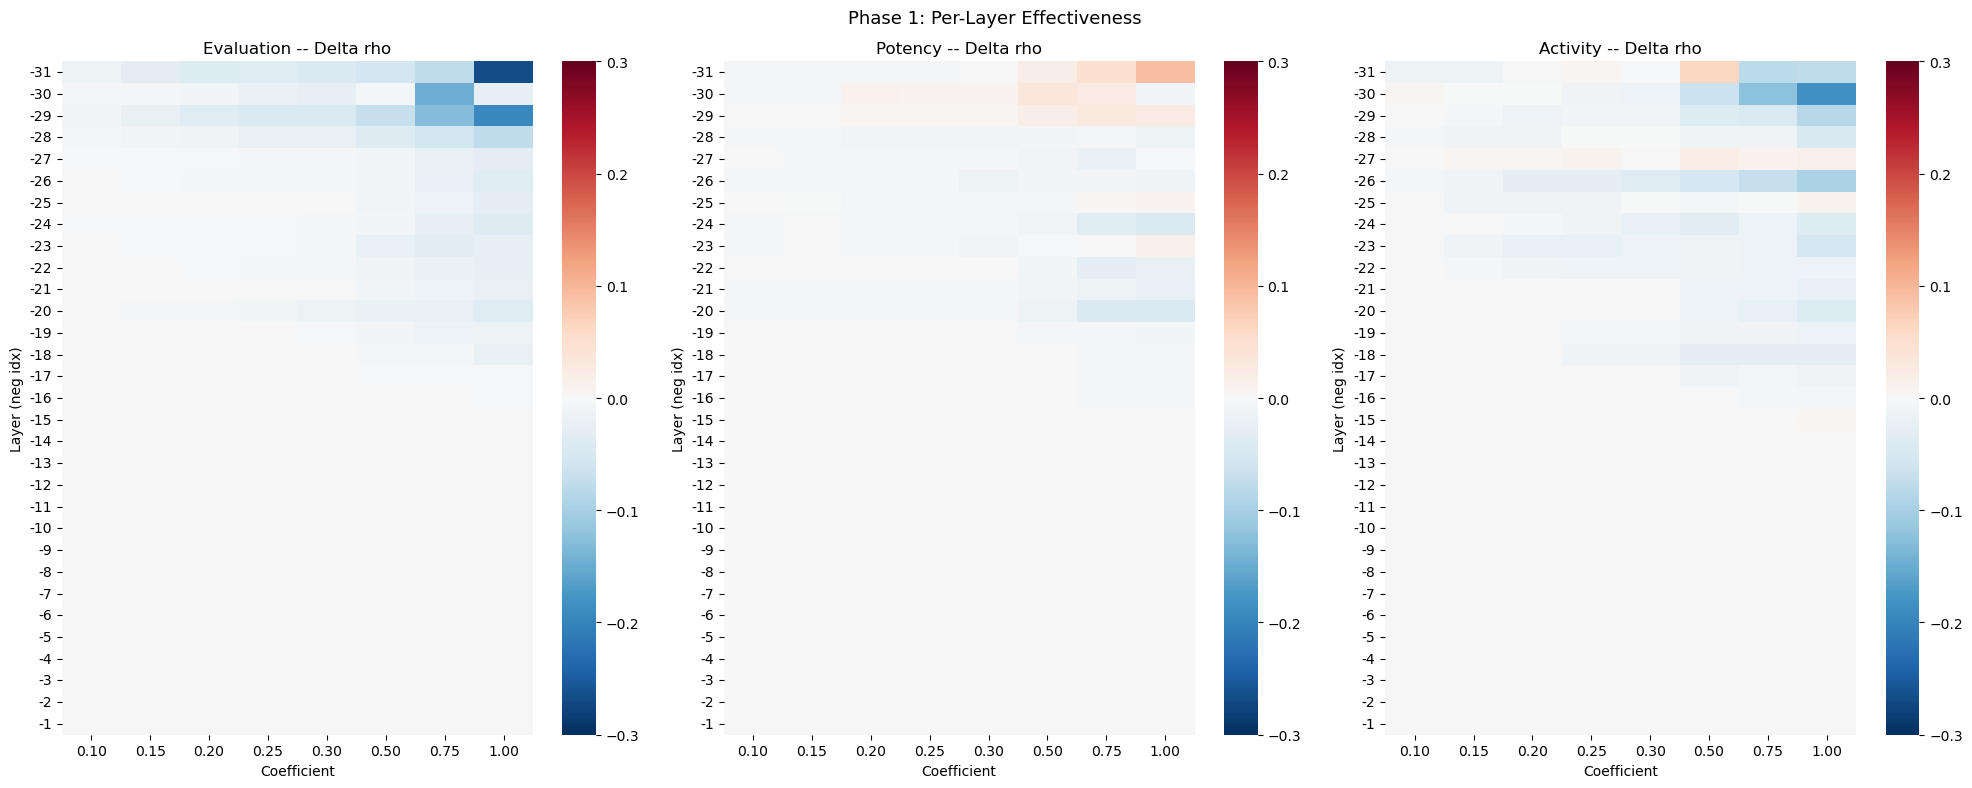

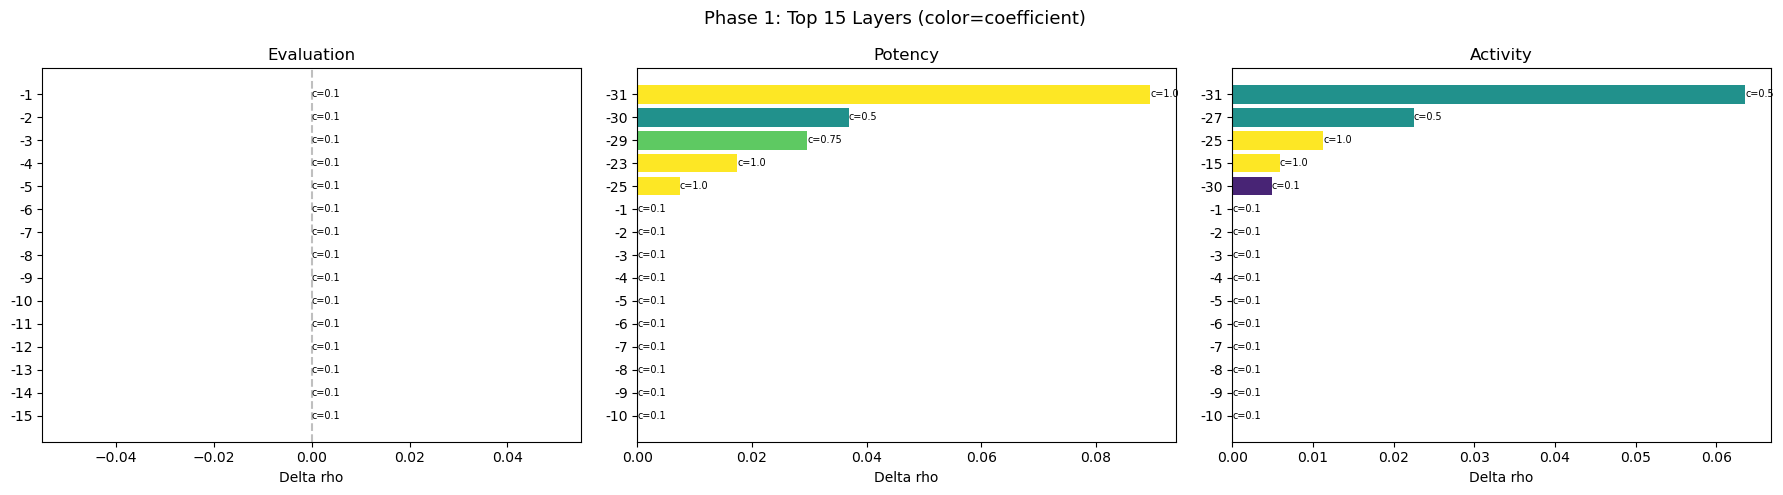

Phase 1 visualizations saved.


In [7]:
# === Cell 7: Phase 1 Visualization ===
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for idx, dim in enumerate(DIMENSIONS):
    rho_base, _ = spearmanr(sweep_base[dim], sweep_gt[dim])
    sorted_layers = sorted(hidden_layers)
    matrix = np.zeros((len(sorted_layers), len(COEFF_CANDIDATES)))
    for i, layer in enumerate(sorted_layers):
        for j, coeff in enumerate(COEFF_CANDIDATES):
            matrix[i, j] = phase1[dim][layer]['all_coeffs'][coeff] - rho_base
    sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3,
        xticklabels=[f"{c:.2f}" for c in COEFF_CANDIDATES],
        yticklabels=[str(l) for l in sorted_layers], ax=axes[idx])
    axes[idx].set_xlabel("Coefficient"); axes[idx].set_ylabel("Layer (neg idx)")
    axes[idx].set_title(f"{dim.capitalize()} -- Delta rho")
plt.suptitle("Phase 1: Per-Layer Effectiveness", fontsize=13)
plt.tight_layout()
plt.savefig("phase1_layer_sweep.png", dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, dim in enumerate(DIMENSIONS):
    ranked = sorted(phase1[dim].items(), key=lambda x: x[1]['best_delta'], reverse=True)[:15]
    labels = [str(l) for l, _ in ranked]
    deltas = [info['best_delta'] for _, info in ranked]
    coeffs = [info['best_coeff'] for _, info in ranked]
    colors = plt.cm.viridis(np.array(coeffs) / max(COEFF_CANDIDATES))
    axes[idx].barh(range(len(labels)), deltas, color=colors)
    axes[idx].set_yticks(range(len(labels))); axes[idx].set_yticklabels(labels)
    axes[idx].invert_yaxis(); axes[idx].set_xlabel("Delta rho")
    axes[idx].set_title(f"{dim.capitalize()}"); axes[idx].axvline(0, color='gray', ls='--', alpha=0.5)
    for i, (d, c) in enumerate(zip(deltas, coeffs)):
        axes[idx].annotate(f"c={c}", xy=(d, i), fontsize=7, va='center')
plt.suptitle("Phase 1: Top 15 Layers (color=coefficient)", fontsize=13)
plt.tight_layout()
plt.savefig("phase1_top_layers.png", dpi=150, bbox_inches='tight'); plt.show()
print("Phase 1 visualizations saved.")

In [8]:
# === Cell 8: Simple Independent Combination ===
# Combine individually-effective layers with their Phase 1 best coefficients.
# Quick: only 3 evaluations on full dataset.

MIN_DELTA = 0.005
simple_results = {}

for steer_dim in DIMENSIONS:
    selected = {l: info['best_coeff'] for l, info in phase1[steer_dim].items()
                if info['best_delta'] > MIN_DELTA}
    if not selected:
        best_l = max(phase1[steer_dim].items(), key=lambda x: x[1]['best_delta'])
        selected = {best_l[0]: best_l[1]['best_coeff']}
    print(f"\n{'='*60}\n{steer_dim.upper()}: {len(selected)} layers")
    for l, c in sorted(selected.items()):
        print(f"  Layer {l:4d}: coeff={c}, delta={phase1[steer_dim][l]['best_delta']:+.3f}")

    neg_layers = list(selected.keys()); pos_layers = neg_to_pos(neg_layers)
    combined = {}
    for nl, c in selected.items():
        kw = {f"{d[0]}_coeff": 0.0 for d in DIMENSIONS}
        kw[f"{steer_dim[0]}_coeff"] = c
        a = make_epa_activations(rep_readers=rep_readers, layers=[nl],
            device=model.device, dtype=model.dtype, normalize=True, **kw)
        combined[neg_to_pos(nl)] = a[nl]
    wrapped_model.unwrap()
    wrapped_model.wrap_block(pos_layers, block_name="decoder_block")
    wrapped_model.set_controller(pos_layers, combined, "decoder_block")

    steered = {d: [] for d in DIMENSIONS}
    for u in tqdm(utterances, desc=f"Eval {steer_dim[:4]}", leave=False):
        for d in DIMENSIONS:
            steered[d].append(compute_likert_distribution(model, tokenizer,
                make_likert_prompt(u['text'], d), d)['expected_value'])
    wrapped_model.reset(); wrapped_model.unwrap()

    corrs = {d: float(spearmanr(steered[d], ground_truth[d])[0]) for d in DIMENSIONS}
    delts = {d: corrs[d] - baseline_rhos[d] for d in DIMENSIONS}
    others = [d for d in DIMENSIONS if d != steer_dim]
    score = corrs[steer_dim] - INTERFERENCE_PENALTY * np.mean([abs(delts[d]) for d in others])
    simple_results[steer_dim] = {"selected": selected, "correlations": corrs, "deltas": delts, "score": score}
    print(f"  On-target: rho={corrs[steer_dim]:+.3f} (delta={delts[steer_dim]:+.3f}), score={score:.3f}")
    for d in others:
        print(f"  {d:12s}: rho={corrs[d]:+.3f} (delta={delts[d]:+.3f})")
print("\nSimple independent done.")


EVALUATION: 1 layers
  Layer   -1: coeff=0.1, delta=+0.000


  On-target: rho=+0.746 (delta=+0.000), score=0.745
  potency     : rho=+0.404 (delta=+0.001)
  activity    : rho=+0.516 (delta=-0.001)

POTENCY: 5 layers
  Layer  -31: coeff=1.0, delta=+0.089
  Layer  -30: coeff=0.5, delta=+0.037
  Layer  -29: coeff=0.75, delta=+0.030
  Layer  -25: coeff=1.0, delta=+0.007
  Layer  -23: coeff=1.0, delta=+0.017


  On-target: rho=+0.195 (delta=-0.208), score=-0.016
  evaluation  : rho=+0.352 (delta=-0.394)
  activity    : rho=+0.067 (delta=-0.449)

ACTIVITY: 4 layers
  Layer  -31: coeff=0.5, delta=+0.064
  Layer  -27: coeff=0.5, delta=+0.022
  Layer  -25: coeff=1.0, delta=+0.011
  Layer  -15: coeff=1.0, delta=+0.006


  On-target: rho=+0.496 (delta=-0.020), score=0.458
  evaluation  : rho=+0.679 (delta=-0.066)
  potency     : rho=+0.317 (delta=-0.086)

Simple independent done.


In [ ]:
# === Cell 9: Phase 2 -- Greedy Forward Selection ===
# Start from best single layer, add layers one at a time.
# Each addition tested with all coefficient candidates.
# ~30 min

TOP_K = 10; MAX_LAYERS = 8; MIN_IMPROVEMENT = 0.005

def eval_combo(selected_lc, steer_dim):
    # Evaluate multi-layer steering on sweep subset.
    nls = list(selected_lc.keys()); pls = neg_to_pos(nls)
    comb = {}
    for nl, c in selected_lc.items():
        kw = {f"{d[0]}_coeff": 0.0 for d in DIMENSIONS}
        kw[f"{steer_dim[0]}_coeff"] = c
        a = make_epa_activations(rep_readers=rep_readers, layers=[nl],
            device=model.device, dtype=model.dtype, normalize=True, **kw)
        comb[neg_to_pos(nl)] = a[nl]
    wrapped_model.unwrap()
    wrapped_model.wrap_block(pls, block_name="decoder_block")
    wrapped_model.set_controller(pls, comb, "decoder_block")
    steered = {d: [] for d in DIMENSIONS}
    for u in sweep_utts:
        for d in DIMENSIONS:
            steered[d].append(compute_likert_distribution(model, tokenizer,
                make_likert_prompt(u['text'], d), d)['expected_value'])
    wrapped_model.reset(); wrapped_model.unwrap()
    corrs = {}; delts = {}
    for d in DIMENSIONS:
        rho, _ = spearmanr(steered[d], sweep_gt[d])
        rho_b, _ = spearmanr(sweep_base[d], sweep_gt[d])
        corrs[d] = float(rho); delts[d] = float(rho - rho_b)
    others = [d for d in DIMENSIONS if d != steer_dim]
    score = corrs[steer_dim] - INTERFERENCE_PENALTY * np.mean([abs(delts[d]) for d in others])
    return {"correlations": corrs, "deltas": delts, "score": score}

print(f"Phase 2: Greedy (top-{TOP_K} layers, max {MAX_LAYERS}, min improvement {MIN_IMPROVEMENT})")
greedy_results = {}

for steer_dim in DIMENSIONS:
    print(f"\n{'='*60}\nGreedy: {steer_dim.upper()}\n{'='*60}")
    ranked = sorted(phase1[steer_dim].items(), key=lambda x: x[1]['best_delta'], reverse=True)[:TOP_K]
    candidates = [l for l, _ in ranked]
    best_l, best_info = ranked[0]
    selected = {best_l: best_info['best_coeff']}
    ev = eval_combo(selected, steer_dim)
    cur_score = ev['score']
    print(f"Step 0: layer {best_l} coeff={best_info['best_coeff']} => score={cur_score:.4f}")
    history = [{"step": 0, "selected": dict(selected), "score": cur_score, **ev}]

    for step in range(1, MAX_LAYERS):
        remaining = [l for l in candidates if l not in selected]
        if not remaining: break
        best_add_score = cur_score; best_add_layer = None; best_add_coeff = None
        for cand_layer in remaining:
            for coeff in COEFF_CANDIDATES:
                trial = {**selected, cand_layer: coeff}
                ev = eval_combo(trial, steer_dim)
                if ev['score'] > best_add_score:
                    best_add_score = ev['score']; best_add_layer = cand_layer; best_add_coeff = coeff
        if best_add_layer is None or (best_add_score - cur_score) < MIN_IMPROVEMENT:
            print(f"Step {step}: no improvement, stopping.")
            break
        selected[best_add_layer] = best_add_coeff
        cur_score = best_add_score
        ev = eval_combo(selected, steer_dim)
        print(f"Step {step}: +layer {best_add_layer} coeff={best_add_coeff} => score={cur_score:.4f} "
              f"(rho={ev['correlations'][steer_dim]:+.3f})")
        history.append({"step": step, "selected": dict(selected), "score": cur_score, **ev})

    greedy_results[steer_dim] = {"selected": dict(selected), "history": history, "score": cur_score}
    print(f"\nFinal: {len(selected)} layers, score={cur_score:.4f}")
    for l, c in sorted(selected.items()):
        print(f"  Layer {l:4d} (pos {neg_to_pos(l):2d}): coeff={c}")

print("\nPhase 2 complete!")

Phase 2: Greedy (top-10 layers, max 8, min improvement 0.005)

Greedy: EVALUATION
Step 0: layer -1 coeff=0.1 => score=0.8082
Step 1: no improvement, stopping.

Final: 1 layers, score=0.8082
  Layer   -1 (pos 31): coeff=0.1

Greedy: POTENCY
Step 0: layer -31 coeff=1.0 => score=0.6667


In [ ]:
# === Cell 10: Final Evaluation on Full Dataset ===
# Validate greedy results on the full 85 utterances with cross-dimension measurement.

final_results = {}
for steer_dim in DIMENSIONS:
    sel = greedy_results[steer_dim]['selected']
    nls = list(sel.keys()); pls = neg_to_pos(nls)
    comb = {}
    for nl, c in sel.items():
        kw = {f"{d[0]}_coeff": 0.0 for d in DIMENSIONS}
        kw[f"{steer_dim[0]}_coeff"] = c
        a = make_epa_activations(rep_readers=rep_readers, layers=[nl],
            device=model.device, dtype=model.dtype, normalize=True, **kw)
        comb[neg_to_pos(nl)] = a[nl]
    wrapped_model.unwrap()
    wrapped_model.wrap_block(pls, block_name="decoder_block")
    wrapped_model.set_controller(pls, comb, "decoder_block")
    steered = {d: [] for d in DIMENSIONS}
    for u in tqdm(utterances, desc=f"Final {steer_dim[:4]}", leave=False):
        for d in DIMENSIONS:
            steered[d].append(compute_likert_distribution(model, tokenizer,
                make_likert_prompt(u['text'], d), d)['expected_value'])
    wrapped_model.reset(); wrapped_model.unwrap()
    corrs = {d: float(spearmanr(steered[d], ground_truth[d])[0]) for d in DIMENSIONS}
    delts = {d: corrs[d] - baseline_rhos[d] for d in DIMENSIONS}
    final_results[steer_dim] = {"selected": sel, "correlations": corrs, "deltas": delts,
        "steered_expected": {d: steered[d] for d in DIMENSIONS}}

# Interference matrix
print("\n=== Final Results (full dataset) ===")
for steer_dim in DIMENSIONS:
    r = final_results[steer_dim]
    print(f"\n{steer_dim.upper()} ({len(r['selected'])} layers):")
    print(f"  On-target: rho={r['correlations'][steer_dim]:+.3f} (delta={r['deltas'][steer_dim]:+.3f})")
    for d in DIMENSIONS:
        if d != steer_dim:
            print(f"  {d:12s}: rho={r['correlations'][d]:+.3f} (delta={r['deltas'][d]:+.3f})")

In [ ]:
# === Cell 11: Final Visualization ===

# --- Interference matrix ---
interf = np.zeros((3, 3)); absol = np.zeros((3, 3))
for i, sd in enumerate(DIMENSIONS):
    for j, md in enumerate(DIMENSIONS):
        interf[i, j] = final_results[sd]['deltas'][md]
        absol[i, j] = final_results[sd]['correlations'][md]
dlabels = [d[:4].capitalize() for d in DIMENSIONS]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(interf, annot=True, fmt="+.3f", cmap="RdBu_r", center=0,
    xticklabels=dlabels, yticklabels=dlabels, ax=axes[0])
axes[0].set_xlabel("Measured"); axes[0].set_ylabel("Steered")
axes[0].set_title("Delta rho (diagonal=target, off-diag=interference)")
sns.heatmap(absol, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-1, vmax=1,
    xticklabels=dlabels, yticklabels=dlabels, ax=axes[1])
axes[1].set_xlabel("Measured"); axes[1].set_ylabel("Steered")
axes[1].set_title("Absolute rho under best greedy steering")
plt.tight_layout(); plt.savefig("v2_interference.png", dpi=150, bbox_inches='tight'); plt.show()

# --- Scatter plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, sd in enumerate(DIMENSIONS):
    sv = final_results[sd]['steered_expected'][sd]
    gv = ground_truth[sd]
    rho, _ = spearmanr(sv, gv)
    axes[idx].scatter(gv, sv, alpha=0.5, s=30, c='#2196F3')
    axes[idx].plot([1,7],[1,7],'k--',alpha=0.3)
    axes[idx].set_xlabel("Ground-Truth Likert"); axes[idx].set_ylabel("Expected (Steered)")
    sel = greedy_results[sd]['selected']
    axes[idx].set_title(f"{sd.capitalize()}\n{len(sel)} layers, rho={rho:+.3f}")
    axes[idx].set_xlim(0.5,7.5); axes[idx].set_ylim(0.5,7.5); axes[idx].set_xticks(range(1,8))
plt.suptitle("Steered vs Ground-Truth (Greedy Selection)", fontsize=13)
plt.tight_layout(); plt.savefig("v2_scatter.png", dpi=150, bbox_inches='tight'); plt.show()

# --- Per-layer coefficient profile ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, sd in enumerate(DIMENSIONS):
    sel = greedy_results[sd]['selected']
    layers_sorted = sorted(sel.keys())
    coeffs = [sel[l] for l in layers_sorted]
    axes[idx].bar([str(l) for l in layers_sorted], coeffs, color='steelblue')
    axes[idx].set_xlabel("Layer (neg idx)"); axes[idx].set_ylabel("Coefficient")
    axes[idx].set_title(f"{sd.capitalize()} -- Per-Layer Coefficients")
    axes[idx].tick_params(axis='x', rotation=45)
plt.suptitle("Greedy-Selected Per-Layer Coefficient Profiles", fontsize=13)
plt.tight_layout(); plt.savefig("v2_coeff_profile.png", dpi=150, bbox_inches='tight'); plt.show()
print("Visualizations saved.")

In [ ]:
# === Cell 12: Save Results ===
output = {
    "metadata": {"model_name": model_name, "tuned_at": datetime.now().isoformat(),
                 "dataset_path": DATASET_PATH, "n_utterances": len(utterances),
                 "n_sweep": len(sweep_utts), "interference_penalty": INTERFERENCE_PENALTY},
    "baseline_correlations": {d: baseline_rhos[d] for d in DIMENSIONS},
    "coeff_candidates": COEFF_CANDIDATES,
    "simple_independent": {},
    "greedy_results": {},
}
for dim in DIMENSIONS:
    # Convert int keys to str for JSON
    si = simple_results[dim]
    output["simple_independent"][dim] = {
        "selected_layers": {str(k): v for k, v in si['selected'].items()},
        "correlations": si['correlations'], "deltas": si['deltas'], "score": si['score'],
    }
    gr = greedy_results[dim]
    output["greedy_results"][dim] = {
        "selected_layers": {str(k): v for k, v in gr['selected'].items()},
        "n_layers": len(gr['selected']), "score": gr['score'],
        "history": [{"step": h["step"], "score": h["score"],
                     "selected": {str(k): v for k, v in h["selected"].items()}}
                    for h in gr['history']],
        "final_correlations": final_results[dim]['correlations'],
        "final_deltas": final_results[dim]['deltas'],
    }

with open("epa_tuning_v2_results.json", 'w') as f:
    json.dump(output, f, indent=2)
print("Results saved to epa_tuning_v2_results.json")
print("\n" + "="*60 + "\nSUMMARY\n" + "="*60)
for dim in DIMENSIONS:
    gr = output['greedy_results'][dim]
    print(f"\n{dim.upper()}: {gr['n_layers']} layers, score={gr['score']:.4f}")
    for l, c in gr['selected_layers'].items():
        print(f"  Layer {l}: coeff={c}")
    print(f"  rho(target)={gr['final_correlations'][dim]:+.3f} "
          f"(delta={gr['final_deltas'][dim]:+.3f})")